# Dispersion Bias, Part (ii) — heavy-tailed, simplified (ex-2)

Same decomposition study as `ex-1`, stripped to essentials: one `DesignSpec` + one call to
`fl_graphics.nine_panel_decomposition(model, design)` per sweep. Each figure shows the
Eq. (17) split per factor — **sin²** (out-of-subspace + in-subspace stack, measured line) /
**gap** (paired measured − theory) / **out-of-subspace share** — with 95% CI bands and gridlines.
Returns are **heavy-tailed** (student-t).

In [ ]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from loguru import logger
logger.remove()  # keep the notebook quiet

from IPython.display import Image, display
from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment
from sim_theorem_partii import DispersionBiasExperiment
from fl_graphics import nine_panel_decomposition, top_row_decomposition, six_panel_decomposition  # pure plotters; render to PNG (Agg)

OUT_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR.mkdir(exist_ok=True)

def show(design, name, *, suptitle=None, progress=True):
    """Run the experiment for `design` (tqdm bar over replicates), then plot + display the
    9-panel decomposition. The plotter only consumes the result frame -- it runs nothing.

    Returns ``(fig, df)`` so the caller can re-save the figure (e.g. ``fig.savefig(..., dpi=300)``
    or as PDF/SVG) or reuse the result frame. A PNG is already written to ``OUT_DIR``."""
    df = run_experiment(model, design, DispersionBiasExperiment(), progress=progress)
    path = OUT_DIR / f"ex2_{name}.png"
    fig, _ = nine_panel_decomposition(df, suptitle=suptitle, out_path=str(path))
    display(Image(filename=str(path)))
    return fig, df

# Canonical diagonal-Gram model (factor 1 market-like, c = [1.25, 1, 1]).
model = ModelSpec(
    k_factors=3,
    factor_vols=[0.16, 0.08, 0.06],
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 0.5},   # market-like factor (c_1 = 1.25)
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)

# Heavy tails: student-t factor & idiosyncratic returns, shared by every sweep below.
HEAVY_TAIL = dict(
    factor_return_sampler={"distribution": "student_t", "df": 6, "loc": 0.0, "scale": 1.0},
    # factor_return_sampler={"distribution": "normal", "loc": 0.0, "scale": 1.0},   # IGNORE --- for comparison with light-tailed case
    idio_return_sampler={"distribution": "student_t", "df": 5, "loc": 0.0, "scale": 1.0},
    # idio_return_sampler={"distribution": "normal", "loc": 0.0, "scale": 1.5},

)
N_REPS, SEED = 1000, 20260511   # bump N_REPS to 1000 for publication-quality CIs
print("ready")

ready


In [20]:
if HEAVY_TAIL["factor_return_sampler"]["distribution"] == "student_t":
    factor_return_print = HEAVY_TAIL["factor_return_sampler"]['distribution']+"("+ str(HEAVY_TAIL['factor_return_sampler']['df'])+")"
elif HEAVY_TAIL["factor_return_sampler"]["distribution"] == "normal":
    factor_return_print = HEAVY_TAIL["factor_return_sampler"]["distribution"]+"("+ str(int(HEAVY_TAIL['factor_return_sampler']['loc'])) + ", " + str(int(HEAVY_TAIL['factor_return_sampler']['scale'])) + ")"


idio_return_print = ""

if HEAVY_TAIL["idio_return_sampler"]["distribution"] == "student_t":
    idio_return_print = HEAVY_TAIL["idio_return_sampler"]['distribution']+"("+ str(HEAVY_TAIL['idio_return_sampler']['df'])+")"
elif HEAVY_TAIL["idio_return_sampler"]["distribution"] == "normal":
    idio_return_print = HEAVY_TAIL["idio_return_sampler"]["distribution"]+"("+ str(int(HEAVY_TAIL['idio_return_sampler']['loc'])) + ", " + str(int(HEAVY_TAIL['idio_return_sampler']['scale'])) + ")"


In [21]:
idio_return_print

'student_t(5)'

## Growing $p$ (fixed $n = 63$)

The theorem becomes exact as $p\to\infty$ — watch the **gap** row collapse to zero.

replicate: 100%|██████████| 1000/1000 [02:14<00:00,  7.45rep/s]


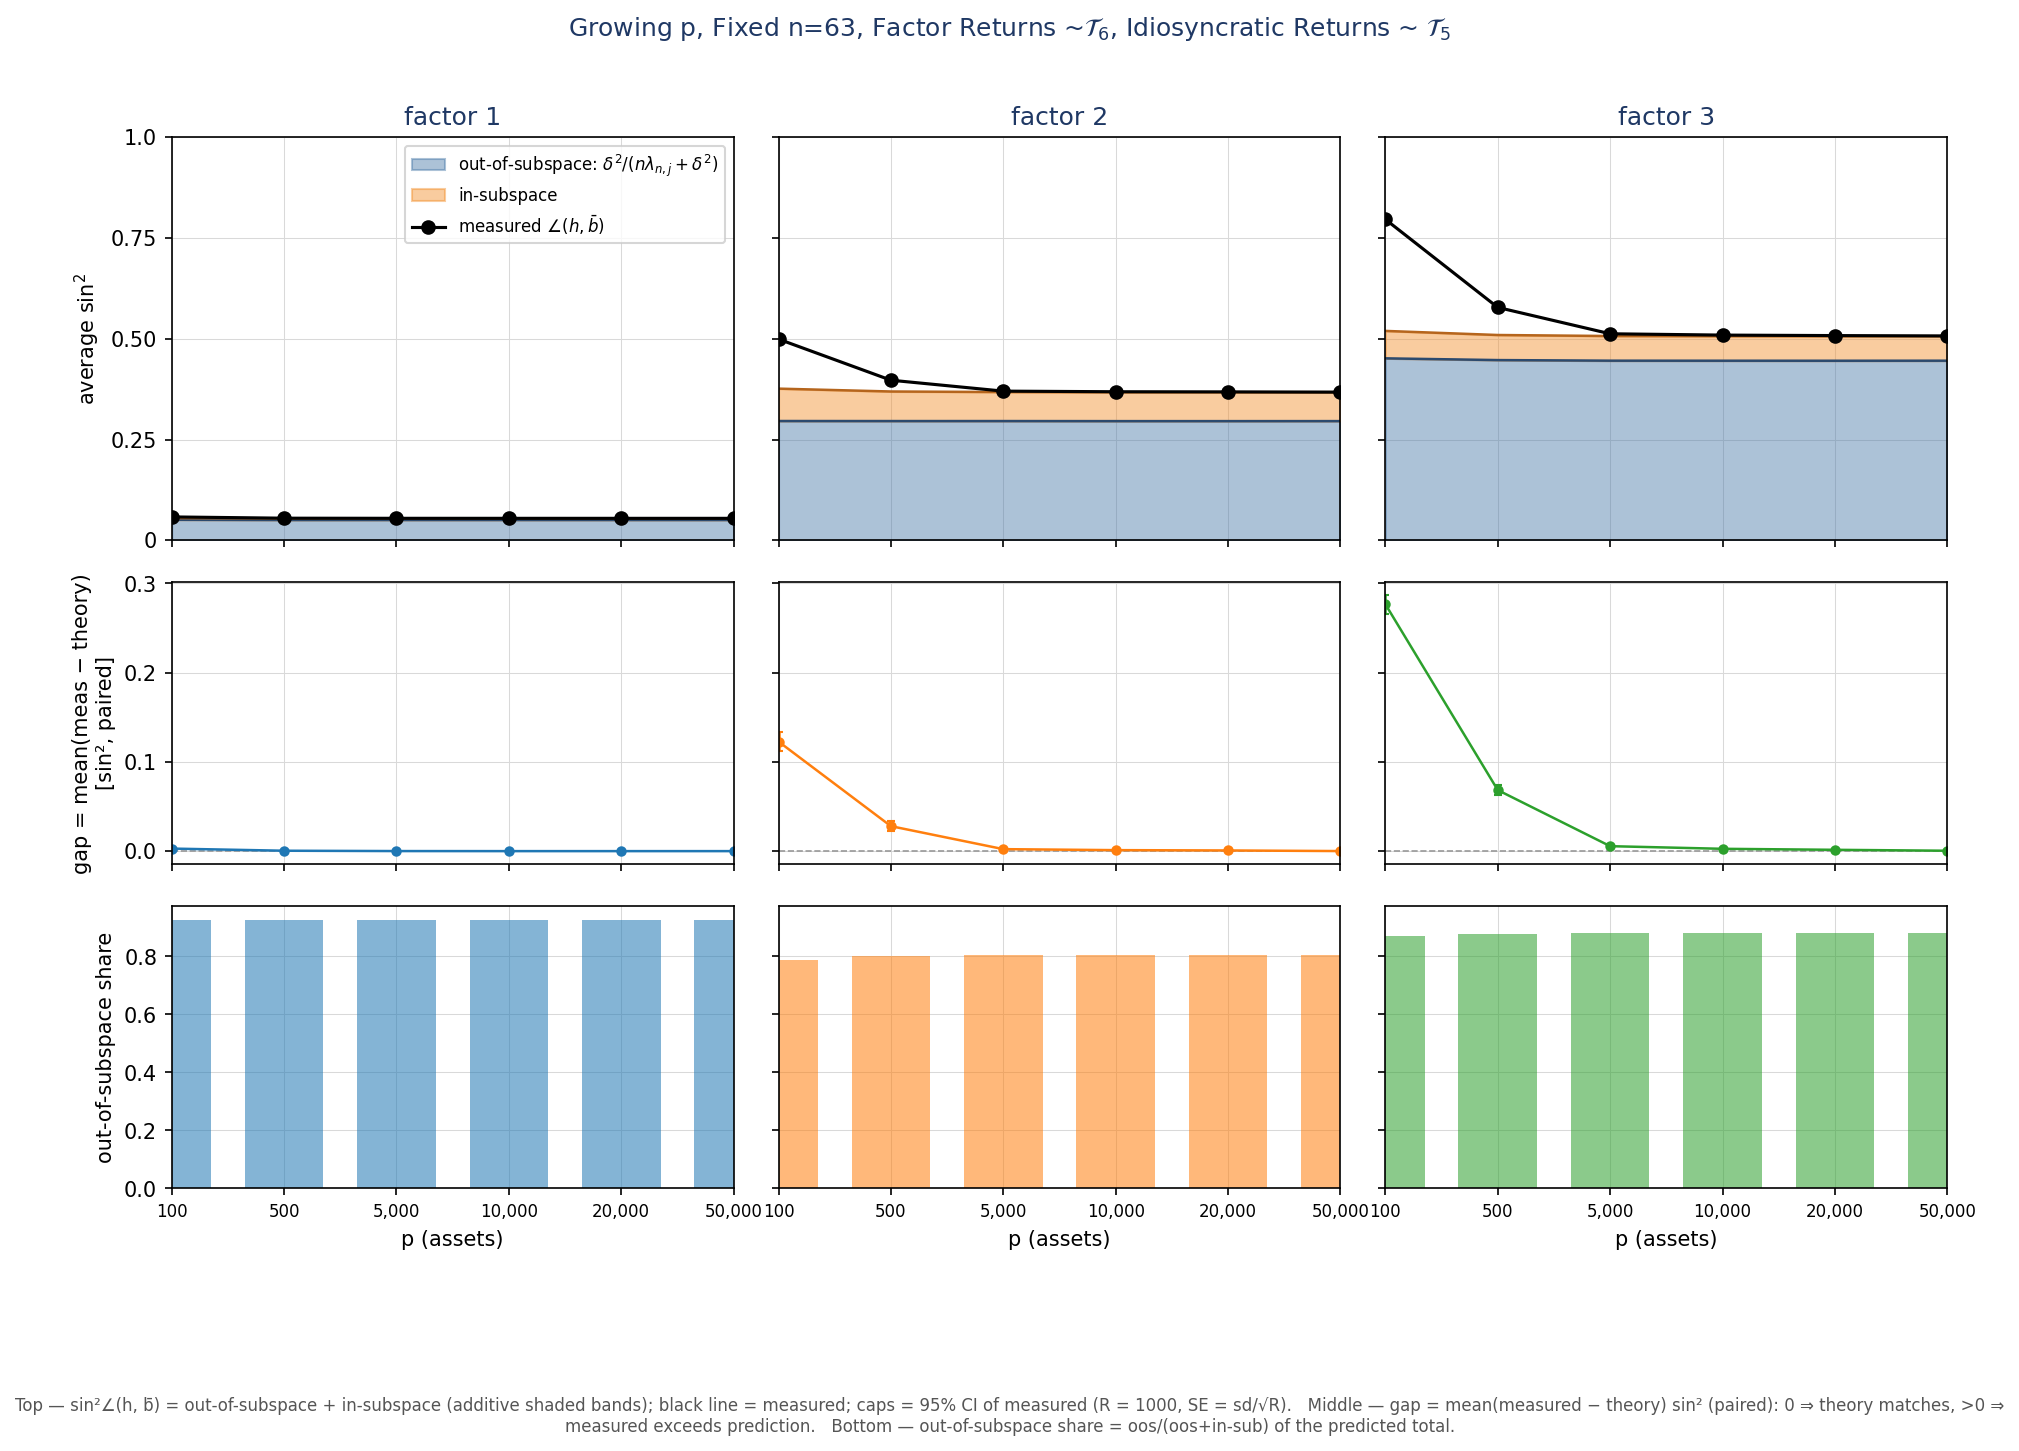

In [22]:
design_p = DesignSpec(
    n_values=[63],
    # p_values=[200, 500, 1000, 2000, 3000, 5000, 10000, 20000],
    p_values = [100, 500, 5000, 10000, 20000, 50000 ],  # for heavy-tailed returns, we need to go bigger on p to see the asymptotic regime
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)
return_print = ""
if "normal" in factor_return_print:
    return_print = r"$\mathcal{N}(0,1)$"
elif "student_t" in factor_return_print:
    return_print = rf"$\mathcal{{T}}_{HEAVY_TAIL['factor_return_sampler']['df']}$"

IR_loc = HEAVY_TAIL['idio_return_sampler']['loc']
IR_scale = HEAVY_TAIL['idio_return_sampler']['scale']

idio_print = ""
if "normal" in idio_return_print:
    idio_print = rf"$\mathcal{{N}}({IR_loc:g}, {IR_scale:g})$"
elif "student_t" in idio_return_print:
    idio_print = rf"$\mathcal{{T}}_{HEAVY_TAIL['idio_return_sampler']['df']}$"



fig_p, df_p = show(design_p, "growing_p",suptitle = f"Growing p, Fixed n=63, Factor Returns ~"+ rf"{return_print}, Idiosyncratic Returns ~ {idio_print}", progress=True)

## Fixed $p = 3000$, growing $n$

Both error pieces shrink as $n$ grows ($F^\top F/n \to \Sigma_F$).

In [23]:
# design_n = DesignSpec(
#     n_values=[20, 30, 45, 60, 63, 90, 120, 180, 250],
#     p_values=[3000],
#     n_reps=N_REPS, random_seed=SEED, sampling="nested", **HEAVY_TAIL,
# )
# fig_n, df_n = show(design_n, "growing_n")

## Fixed $p = 3000$, growing $n$ — `nest_time=True`

Nesting the time axis (each $n$ is a prefix of one $n_{\max}$ draw) gives a smoother curve.

replicate: 100%|██████████| 1000/1000 [00:20<00:00, 49.79rep/s]


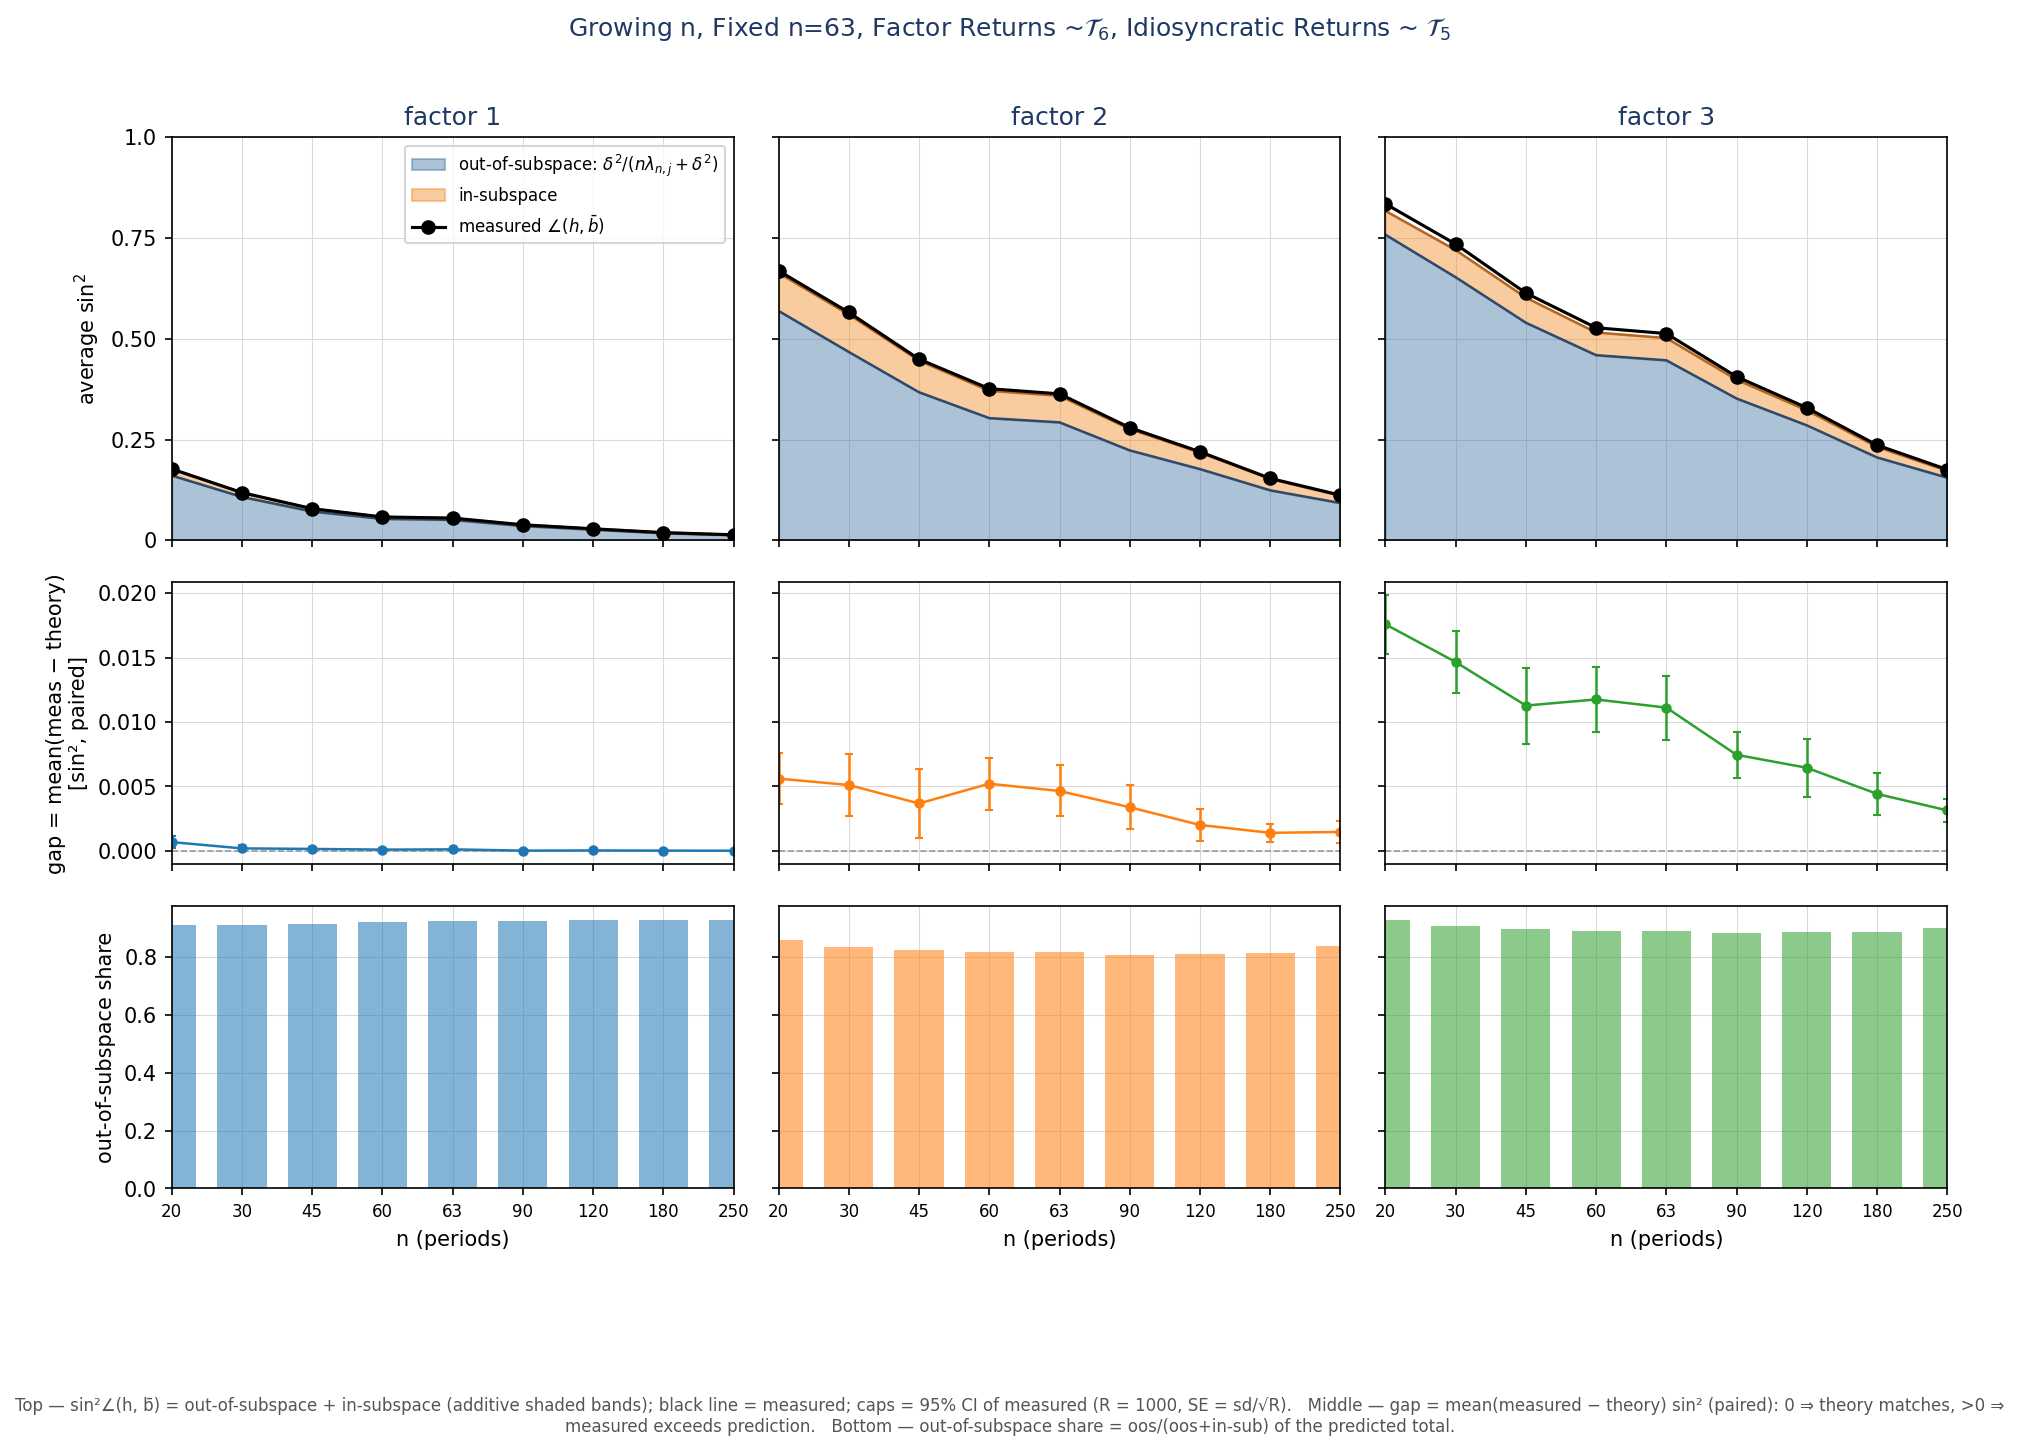

In [24]:
design_nt = DesignSpec(
    n_values=[20, 30, 45, 60, 63, 90, 120, 180, 250],
    p_values=[3000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)
fig_nt, df_nt = show(design_nt, "nest_time",
     suptitle = f"Growing n, Fixed n=63, Factor Returns ~"+ rf"{return_print}, Idiosyncratic Returns ~ {idio_print}", progress=True)

## Top-row "band" view (standalone)

The 9-panel top row on its own, one panel per factor — rendered by
`fl_graphics.top_row_decomposition`, which shares the exact drawing helper (`_np_top_panel`) with the
full 9-panel figure, so the styling can't drift. Light **blue** = out-of-subspace floor
$\delta^2/(n\lambda_{n,j}+\delta^2)$, **orange** = in-subspace, each with a topline that moves with
the swept axis; **black dots** (measured $\sin^2\angle$, 95% CI caps) ride on top and settle onto the
floor as $p\to\infty$. Pass `topline_ci=True` to overlay translucent 95% CI ribbons on the
floor/total toplines.

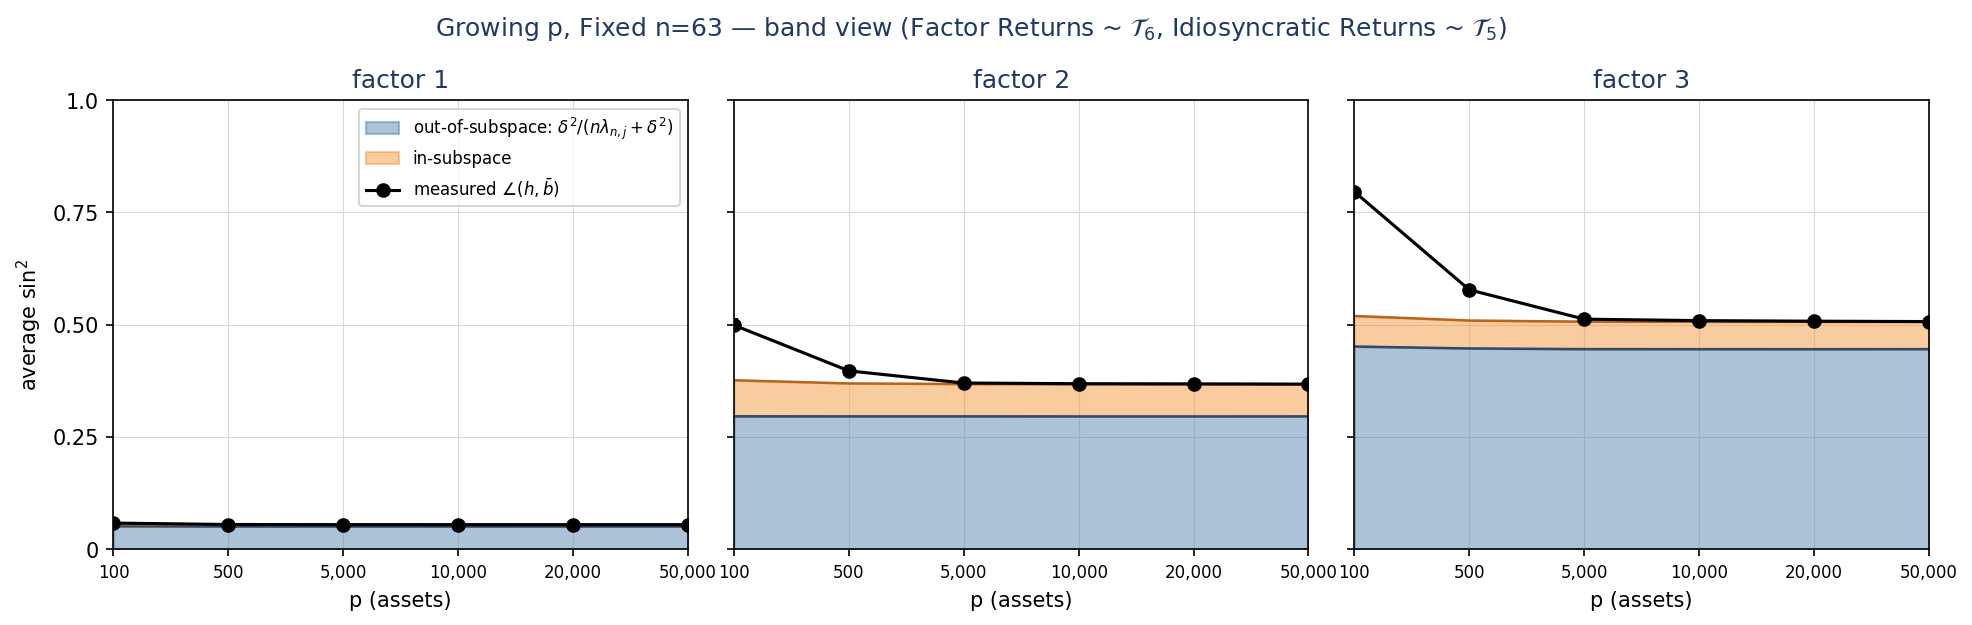

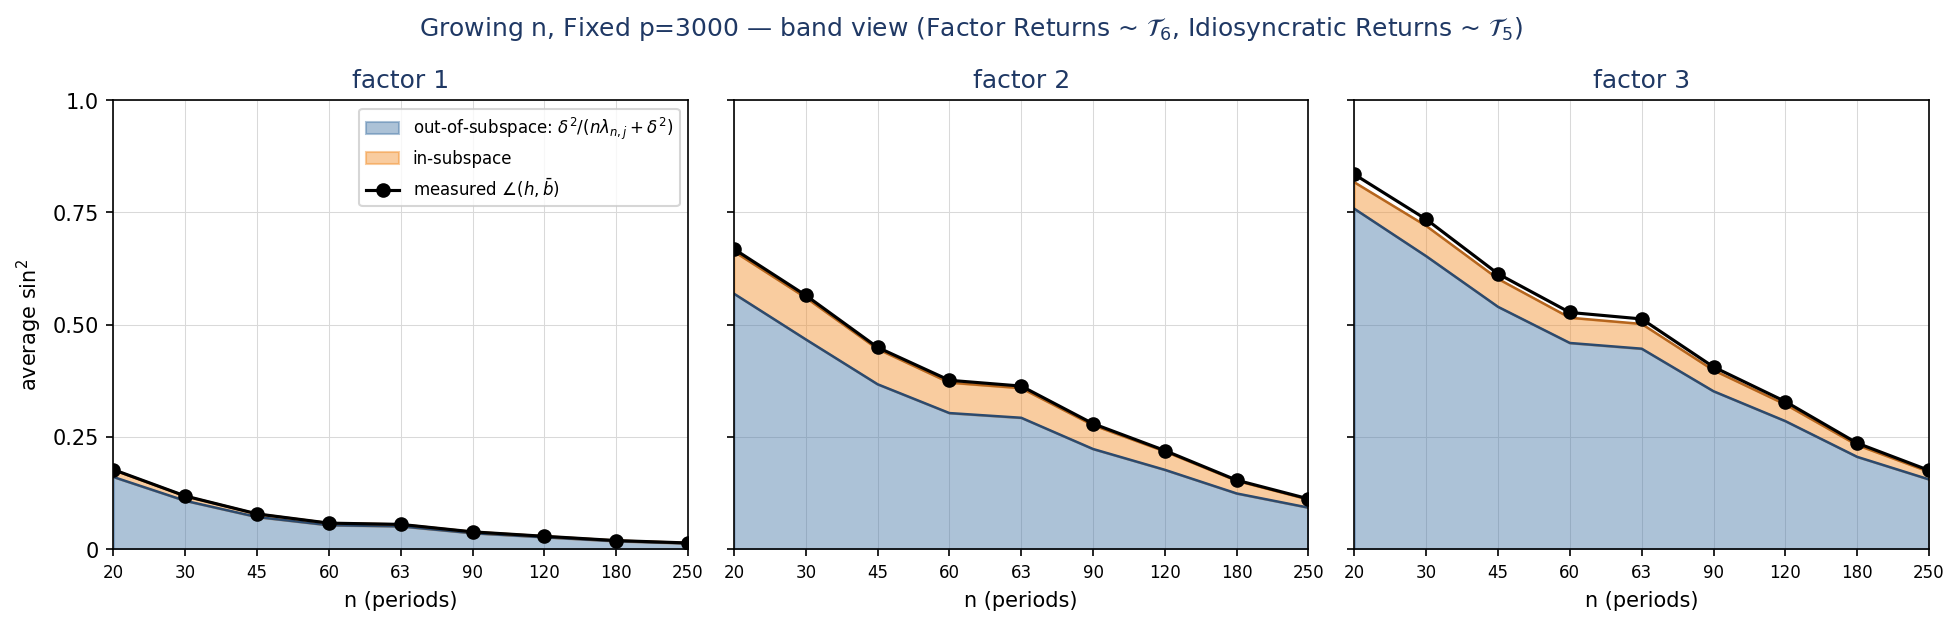

In [25]:
# Standalone top-row "band" view — same shared helper / styling as the 9-panel top row
# (fl_graphics.top_row_decomposition). Pass topline_ci=True to overlay floor/total 95% CI ribbons.
_strip_path_p = OUT_DIR / "ex2_strips_growing_p.png"
_strip_path_n = OUT_DIR / "ex2_strips_growing_n.png"
fig_strip_p, _ = top_row_decomposition(
    df_p, key="p", out_path=str(_strip_path_p),
    suptitle=rf"Growing p, Fixed n=63 — band view (Factor Returns ~ {return_print}, "
             rf"Idiosyncratic Returns ~ {idio_print})",
)
fig_strip_n, _ = top_row_decomposition(
    df_nt, key="n", out_path=str(_strip_path_n),
    suptitle=rf"Growing n, Fixed p=3000 — band view (Factor Returns ~ {return_print}, "
             rf"Idiosyncratic Returns ~ {idio_print})",
)
display(Image(filename=str(_strip_path_p)))
display(Image(filename=str(_strip_path_n)))

## Six-panel view — band top row + per-rep gap boxplots

Same band top row as the 9-panel figure, but the second row swaps the mean±CI **gap** line for a
**boxplot of the per-replicate gap** ($\sin^2_j - \text{rhs}$) at each swept value — showing the
spread across trajectories rather than just the mean. (Third row deliberately omitted for now.)
Rendered by `fl_graphics.six_panel_decomposition`; reuses the shared `_np_top_panel` so the top row
can't drift from the 9-panel one.

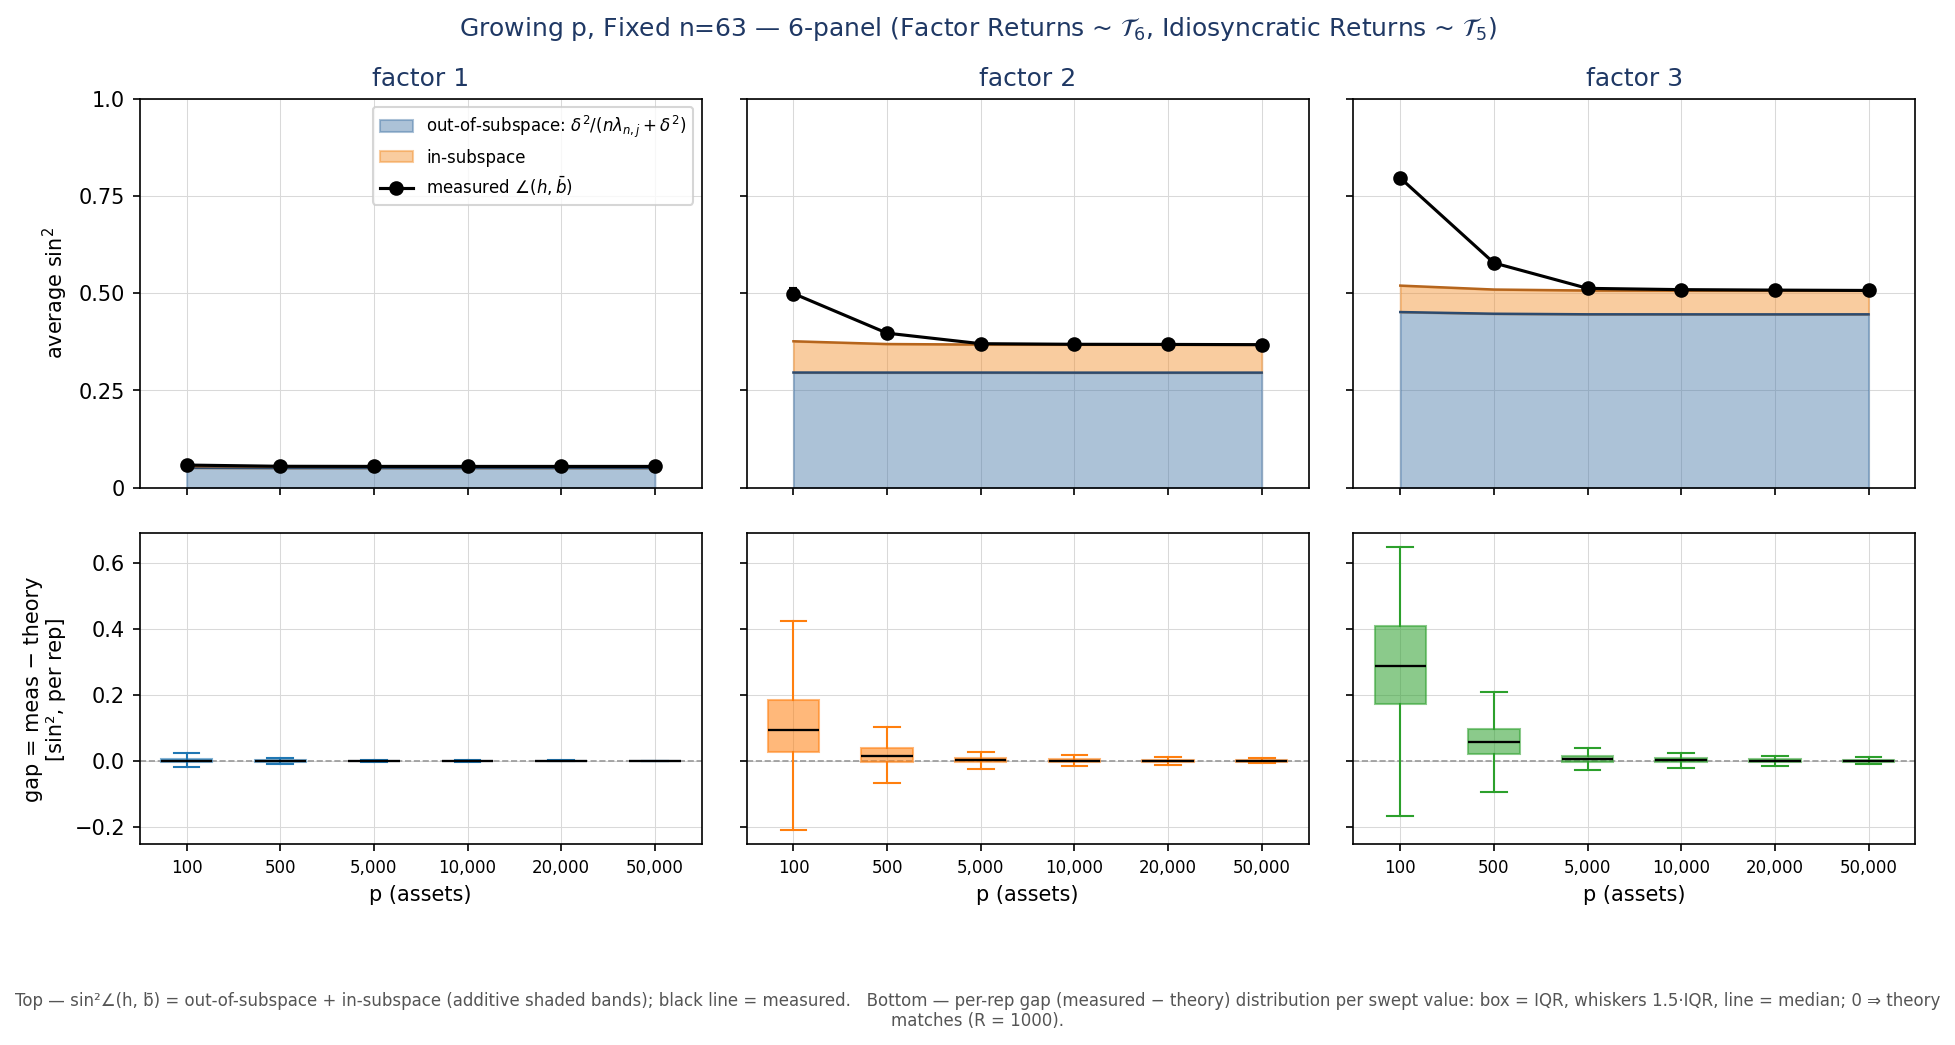

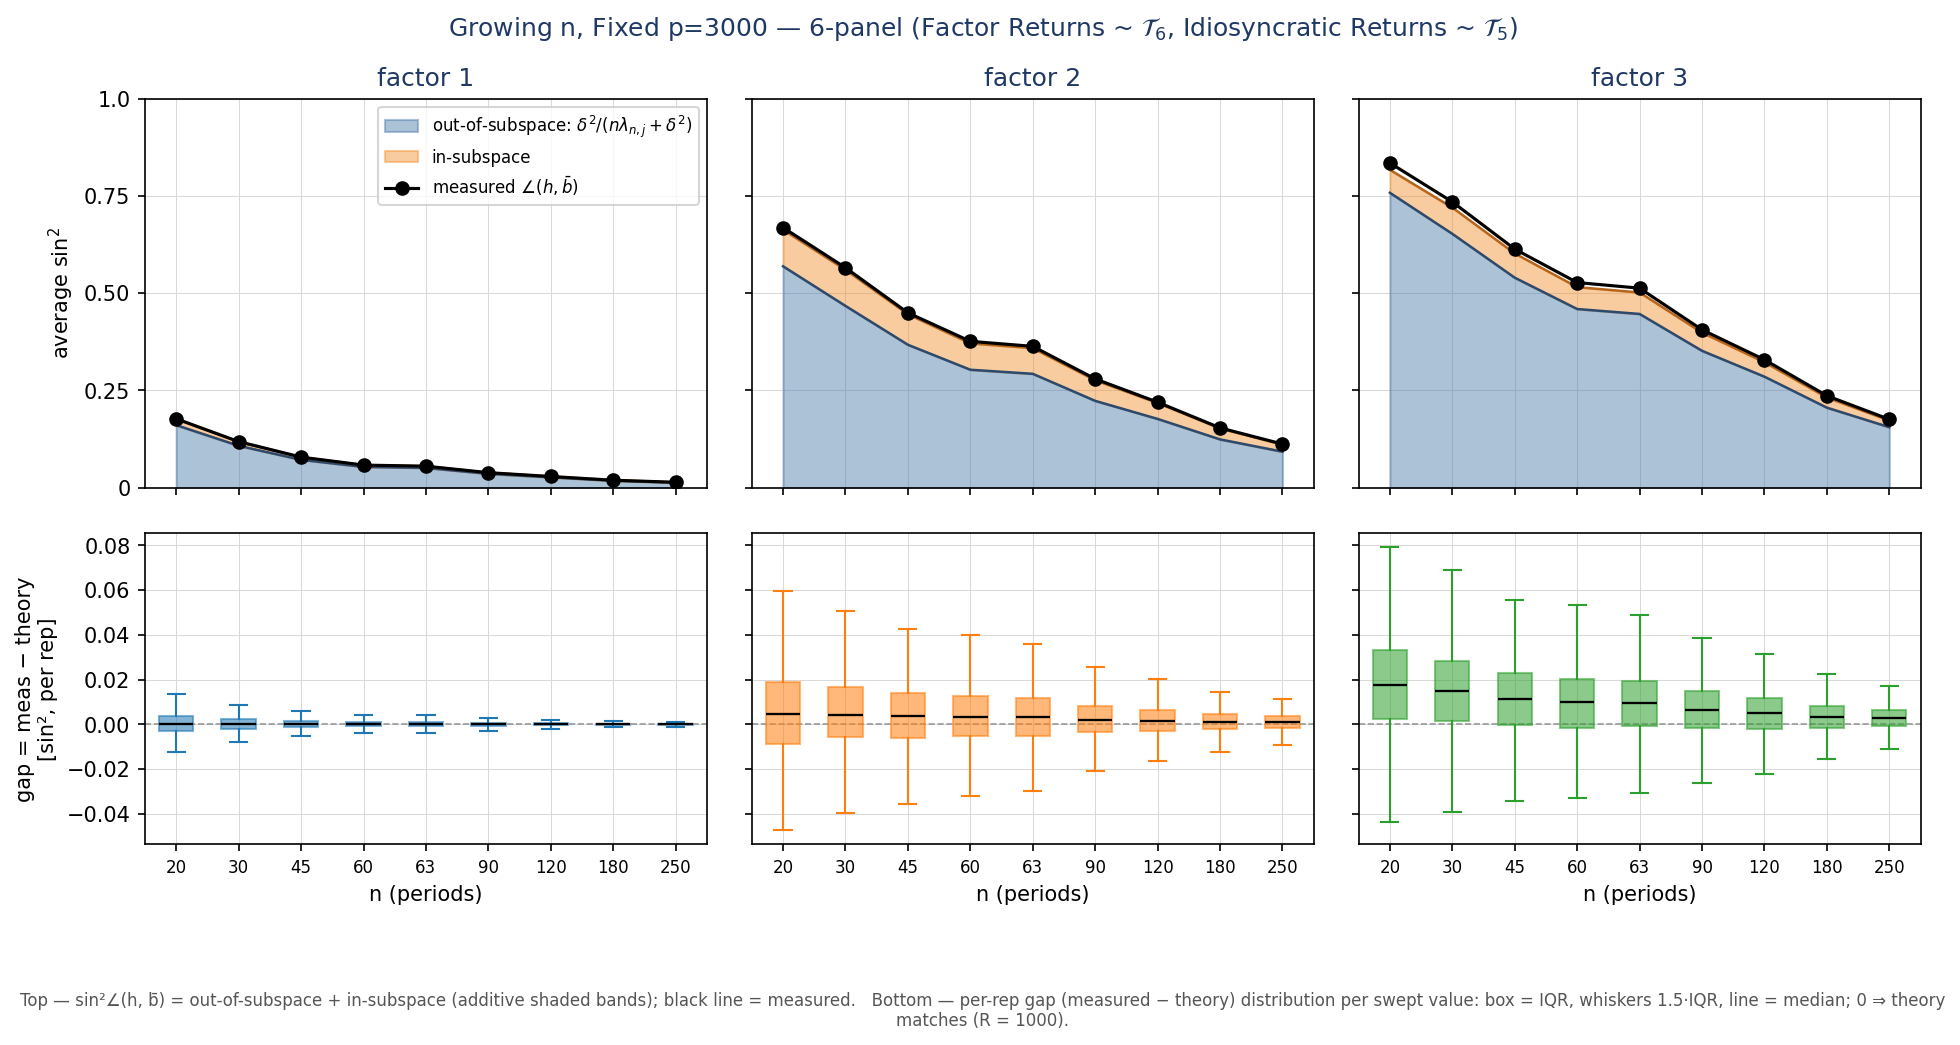

In [26]:
# Six-panel view: band top row + per-rep gap boxplots (2nd row). Reuses the already-computed
# df_p / df_nt — no re-run. Pass topline_ci=True to add floor/total CI ribbons on the top row.
_six_path_p = OUT_DIR / "ex2_six_growing_p.png"
_six_path_n = OUT_DIR / "ex2_six_growing_n.png"
fig_six_p, _ = six_panel_decomposition(
    df_p, key="p", out_path=str(_six_path_p),
    suptitle=rf"Growing p, Fixed n=63 — 6-panel (Factor Returns ~ {return_print}, "
             rf"Idiosyncratic Returns ~ {idio_print})",
)
fig_six_n, _ = six_panel_decomposition(
    df_nt, key="n", out_path=str(_six_path_n),
    suptitle=rf"Growing n, Fixed p=3000 — 6-panel (Factor Returns ~ {return_print}, "
             rf"Idiosyncratic Returns ~ {idio_print})",
)
display(Image(filename=str(_six_path_p)))
display(Image(filename=str(_six_path_n)))

In [ ]:
#### SAVE FIGURES


# fig_p.savefig(OUT_DIR / "v2_heavy_tail_growing_p.pdf", dpi=300, bbox_inches="tight")
# fig_nt.savefig(OUT_DIR / "v2_heavy_tail_growing_n.pdf", dpi=300, bbox_inches="tight")
# fig_strip_p.savefig(OUT_DIR / "v2_heavy_tail_growing_p_top_row.pdf", dpi=300, bbox_inches="tight")
# fig_strip_n.savefig(OUT_DIR / "v2_heavy_tail_growing_n_top_row.pdf", dpi=300, bbox_inches="tight")
# fig_six_p.savefig(OUT_DIR / "v3_heavy_tail_growing_p_six_panel.pdf", dpi=300, bbox_inches="tight")
# fig_six_n.savefig(OUT_DIR / "v3_heavy_tail_growing_n_six_panel.pdf", dpi=300, bbox_inches="tight")